# EDA — Allstate Claims Severity

In [1]:
import sys
sys.path.insert(0, '..')

import duckdb
import matplotlib.pyplot as plt
import numpy as np
from src.load_data import load_train

df = load_train('../data/raw/train.csv')

train: (188319, 132)


  dropped 1 row(s) with null loss


## Shape and column groups

In [2]:
cat_cols = [c for c in df.columns if c.startswith('cat')]
cont_cols = [c for c in df.columns if c.startswith('cont')]

print(f"Rows: {len(df):,}")
print(f"Categorical features: {len(cat_cols)}")
print(f"Continuous features: {len(cont_cols)}")

Rows: 188,318
Categorical features: 116
Continuous features: 14


## Null check

In [3]:
null_counts = df.isnull().sum()
cols_with_nulls = null_counts[null_counts > 0]
print(f"Columns with nulls: {len(cols_with_nulls)}")
if len(cols_with_nulls) > 0:
    print(cols_with_nulls.head(10).to_string())

Columns with nulls: 0


## Target distribution

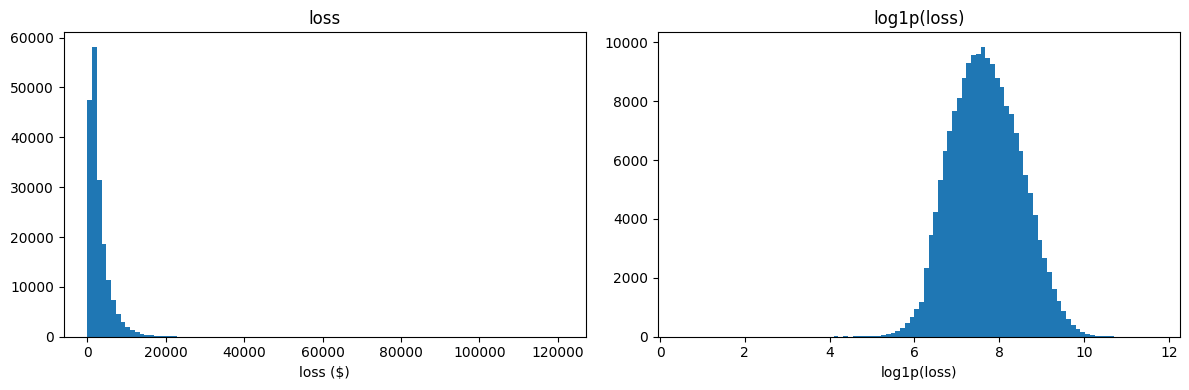

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['loss'], bins=100, edgecolor='none')
axes[0].set_title('loss')
axes[0].set_xlabel('loss ($)')

axes[1].hist(np.log1p(df['loss']), bins=100, edgecolor='none')
axes[1].set_title('log1p(loss)')
axes[1].set_xlabel('log1p(loss)')

plt.tight_layout()
plt.show()

## Top categorical frequencies

In [5]:
import pandas as pd

pd.concat([
    df[col].value_counts().head(5).rename_axis('value').reset_index().assign(feature=col)
    for col in cat_cols[:5]
], ignore_index=True)[['feature', 'value', 'count']]

,feature,value,count
0,cat1,A,141550
1,cat1,B,46768
2,cat2,A,106721
3,cat2,B,81597
4,cat3,A,177993
5,cat3,B,10325
6,cat4,A,128395
7,cat4,B,59923
8,cat5,A,123737
9,cat5,B,64581


## DuckDB SQL

In [6]:
con = duckdb.connect()
con.register('claims', df)

In [7]:
# Row count
con.execute('SELECT COUNT(*) AS row_count FROM claims').df()

,row_count
0,188318


In [8]:
# Loss summary stats
con.execute('''
    SELECT
        ROUND(MIN(loss), 2)    AS min,
        ROUND(AVG(loss), 2)    AS mean,
        ROUND(MEDIAN(loss), 2) AS median,
        ROUND(MAX(loss), 2)    AS max
    FROM claims
''').df()

,min,mean,median,max
0,0.67,3037.34,2115.57,121012.25


In [9]:
# Average loss by cat1
con.execute('''
    SELECT cat1, ROUND(AVG(loss), 2) AS avg_loss, COUNT(*) AS n
    FROM claims
    GROUP BY cat1
    ORDER BY avg_loss DESC
''').df()

,cat1,avg_loss,n
0,A,3408.09,141550
1,B,1915.20,46768


In [10]:
# Top categories by count (cat2)
con.execute('''
    SELECT cat2, COUNT(*) AS n
    FROM claims
    GROUP BY cat2
    ORDER BY n DESC
    LIMIT 10
''').df()

,cat2,n
0,A,106721
1,B,81597


In [11]:
# High-loss rows (loss > 10000)
con.execute('''
    SELECT COUNT(*) AS high_loss_count
    FROM claims
    WHERE loss > 10000
''').df()

,high_loss_count
0,5880


## Observations

1. **Skewed target**: `loss` is heavily right-skewed with a long tail of large claims. `log1p(loss)` is much closer to normal — we'll train on the log-transformed target.
2. **No nulls after loading**: `load_train` drops the one malformed row (which had a null `loss`), leaving 0 null columns. Numeric nulls would be filled with train medians at the feature engineering stage if any existed.
3. **Categorical spread**: Most categorical features are dominated by one or two values (e.g. `cat1` is ~75% "A"). Unknown categories (values not seen in training) will map to 0 under frequency encoding; known categories always map to their frequency count.
4. **Mean vs median**: Mean loss ($3,037) is substantially higher than the median ($2,116), confirming the outlier effect — a small number of very large claims pull the average up.